# K-SVD vs $\ell_1$-K-SVD: PSNR & SSIM Comparison


## 1. Setup

In [1]:
import sys, os

# Make both algorithm packages importable (notebook lives in Project/)
sys.path.insert(0, os.path.join(os.getcwd(), 'PyKSVD'))
sys.path.insert(0, os.path.join(os.getcwd(), 'Pyl1KSVD'))

import numpy as np
import matplotlib.pyplot as plt
import glob
from PIL import Image
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

from pyksvd.pyksvd   import KSVD
from pyl1ksvd.pyl1ksvd import L1KSVD

np.random.seed(42)
print('All imports OK')

All imports OK


## 2. Hyperparameters

> **Demo note:** Parameters below are chosen for reasonable notebook runtime.
> For publication-quality results, increase `K`, `MAX_ITER`, and `N_TRAIN_PATCHES`.

In [27]:
# ── image / patch settings ────────────────────────────────────────────────────
IMAGE_SIZE   = 128    # resize all images to (IMAGE_SIZE x IMAGE_SIZE)
PATCH_SIZE   = 8      # 8×8 patches  →  64-dimensional signals

# ── dictionary settings ───────────────────────────────────────────────────────
K            = 128     # number of atoms
N_TRAIN_PATCHES = 1000  # patches to use for training (subsampled)

# ── K-SVD settings ────────────────────────────────────────────────────────────
T0           = 4      # sparsity (max non-zeros per signal)
KSVD_ITER    = 15     # outer iterations

# ── l1-K-SVD settings (Algorithm 1, Mukherjee et al. 2016) ───────────────────
LAM          = 1.0   # lambda: l1 regularisation strength
N_IRLS_SP    = 10     # IRLS iters – sparse coding
N_IRLS_DICT  = 10      # IRLS iters – dictionary update (J in paper)
THR_FRAC     = 0.001   # pruning threshold = 0.03 * ||X||_F  (paper default)
L1_ITER      = 15     # outer iterations

# ── test noise settings ───────────────────────────────────────────────────────
SIGMA_GAUSS  = 20 / 255      # Gaussian noise std  (σ = 25 on 0-255 scale)
SCALE_LAP    = SIGMA_GAUSS / np.sqrt(2)   # Laplacian scale (same power)
REMOVE_RATIO = 0.20          # fraction of pixels removed (inpainting)

# ── data paths (relative to notebook location = Project/) ────────────────────
TRAIN_DIR  = 'PyKSVD/data/train/impressionism/'
TEST_PATH  = 'PyKSVD/data/test/impressionism/134.jpg'

## 3. Utility Functions

In [28]:
def load_image(path, size):
    """Load a JPEG, resize, return float32 array in [0, 1], shape (H, W, 3)."""
    img = Image.open(path).convert('RGB').resize((size, size))
    return np.array(img, dtype=np.float32) / 255.0


def extract_patches(image, patch_size):
    """Non-overlapping patch extraction. Returns (N_patches, patch_size^2, 3)."""
    H, W, C = image.shape
    patches = []
    for i in range(0, H - patch_size + 1, patch_size):
        for j in range(0, W - patch_size + 1, patch_size):
            patches.append(image[i:i+patch_size, j:j+patch_size, :]
                           .reshape(patch_size * patch_size, C))
    return np.array(patches)   # (N_patches, d, C)


def assemble_image(patches, H, W, patch_size):
    """Reassemble non-overlapping patches into an image (H, W, C)."""
    C = patches.shape[-1]
    img = np.zeros((H, W, C), dtype=np.float32)
    idx = 0
    for i in range(0, H - patch_size + 1, patch_size):
        for j in range(0, W - patch_size + 1, patch_size):
            img[i:i+patch_size, j:j+patch_size, :] = (
                patches[idx].reshape(patch_size, patch_size, C)
            )
            idx += 1
    return img


def denoise_image(image, ksvd_models, l1ksvd_models, patch_size):
    """
    Denoise/reconstruct a degraded image using the learned per-channel models.
    Works for any degradation (Gaussian noise, Laplacian noise, inpainting)
    as long as all pixels are present (non-null).

    Returns:
        ksvd_recon  : (H, W, C) float32, clipped to [0,1]
        l1ksvd_recon: (H, W, C) float32, clipped to [0,1]
    """
    H, W, C = image.shape
    patches = extract_patches(image, patch_size)   # (N, d, C)
    N = patches.shape[0]
    d = patch_size * patch_size

    ksvd_patches   = np.zeros_like(patches)
    l1ksvd_patches = np.zeros_like(patches)

    for c in range(C):
        Y_c = patches[:, :, c].T   # (d, N)

        # K-SVD reconstruction
        X_k, D_k = ksvd_models[c].transform_with_mean(Y_c)
        ksvd_patches[:, :, c] = (D_k @ X_k).T

        # l1-K-SVD reconstruction
        X_l, D_l = l1ksvd_models[c].transform_with_mean(Y_c)
        l1ksvd_patches[:, :, c] = (D_l @ X_l).T

    ksvd_recon   = np.clip(assemble_image(ksvd_patches,   H, W, patch_size), 0, 1)
    l1ksvd_recon = np.clip(assemble_image(l1ksvd_patches, H, W, patch_size), 0, 1)
    return ksvd_recon, l1ksvd_recon


def inpaint_image(corrupted, ksvd_models, l1ksvd_models, patch_size):
    """
    Reconstruct an image with missing (zero) pixels using both models.
    Uses the null-value-aware transform.
    """
    H, W, C = corrupted.shape
    patches = extract_patches(corrupted, patch_size)   # (N, d, C)

    ksvd_patches   = np.zeros_like(patches)
    l1ksvd_patches = np.zeros_like(patches)

    for c in range(C):
        Y_c = patches[:, :, c].T   # (d, N)

        # K-SVD uses the null-value-aware transform
        X_k, D_k = ksvd_models[c].transform_with_mean_signal_with_null_values(Y_c)
        ksvd_patches[:, :, c] = (D_k @ X_k).T

        # l1-K-SVD same
        X_l, D_l = l1ksvd_models[c].transform_with_mean_signal_with_null_values(Y_c)
        l1ksvd_patches[:, :, c] = (D_l @ X_l).T

    ksvd_recon   = np.clip(assemble_image(ksvd_patches,   H, W, patch_size), 0, 1)
    l1ksvd_recon = np.clip(assemble_image(l1ksvd_patches, H, W, patch_size), 0, 1)
    return ksvd_recon, l1ksvd_recon


def compute_metrics(clean, restored):
    """Return (PSNR in dB, SSIM) between two images in [0,1]."""
    p = psnr(clean, restored, data_range=1.0)
    s = ssim(clean, restored, data_range=1.0, channel_axis=2)
    return p, s


def show_comparison(clean, degraded, ksvd_rec, l1ksvd_rec,
                    title_deg, psnr_k, ssim_k, psnr_l, ssim_l):
    """4-panel figure: clean | degraded | K-SVD | l1-K-SVD."""
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    data   = [clean,    degraded,   ksvd_rec,                   l1ksvd_rec]
    titles = ['Clean', title_deg,
              f'K-SVD\nPSNR={psnr_k:.2f} dB  SSIM={ssim_k:.3f}',
              f'$\\ell_1$-K-SVD\nPSNR={psnr_l:.2f} dB  SSIM={ssim_l:.3f}']
    for ax, img, t in zip(axes, data, titles):
        ax.imshow(np.clip(img, 0, 1))
        ax.set_title(t, fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

print('Utility functions defined.')

Utility functions defined.


## 4. Load Training Data & Extract Patches

In [29]:
train_files = sorted(glob.glob(os.path.join(TRAIN_DIR, '*.jpg')))
print(f'Found {len(train_files)} training images.')

# Collect patches from all training images
all_patches = []   # list of (d, C) arrays
for f in train_files:
    img = load_image(f, IMAGE_SIZE)
    p   = extract_patches(img, PATCH_SIZE)   # (N_p, d, C)
    all_patches.append(p)

all_patches = np.concatenate(all_patches, axis=0)   # (N_total, d, C)
N_total = all_patches.shape[0]
d       = PATCH_SIZE * PATCH_SIZE
print(f'Total patches: {N_total}  |  patch dimension d={d}')

# Subsample for manageable training time
if N_total > N_TRAIN_PATCHES:
    idx = np.random.choice(N_total, N_TRAIN_PATCHES, replace=False)
    train_patches = all_patches[idx]    # (N_TRAIN_PATCHES, d, C)
    print(f'Subsampled to {N_TRAIN_PATCHES} patches.')
else:
    train_patches = all_patches

# Split into per-channel matrices  (d, N_TRAIN_PATCHES)
Y_train = [train_patches[:, :, c].T for c in range(3)]   # list of 3 arrays
channel_names = ['Red', 'Green', 'Blue']
print('Training matrices ready.')

Found 34 training images.
Total patches: 8704  |  patch dimension d=64
Subsampled to 1000 patches.
Training matrices ready.


## 5. Train K-SVD (one model per channel)

In [30]:
ksvd_models = []
for c, name in enumerate(channel_names):
    print(f'\n── K-SVD  channel: {name} ──')
    m = KSVD(K=K, T0=T0, max_iter=KSVD_ITER)
    m.fit_with_mean(Y_train[c], verbose=False)
    ksvd_models.append(m)

print('\nK-SVD training complete.')


── K-SVD  channel: Red ──
Fitting model with mean ...


Current error: 25.3935:   0%|          | 0/15 [00:00<?, ?it/s]


Converged at iteration 0, delta: 0.0000
Final error after fitting: 25.3935

── K-SVD  channel: Green ──
Fitting model with mean ...


Current error: 22.5142:   0%|          | 0/15 [00:00<?, ?it/s]


Converged at iteration 0, delta: 0.0000
Final error after fitting: 22.5142

── K-SVD  channel: Blue ──
Fitting model with mean ...


Current error: 18.4794:   0%|          | 0/15 [00:00<?, ?it/s]

Converged at iteration 0, delta: 0.0000
Final error after fitting: 18.4794

K-SVD training complete.


## 6. Train $\ell_1$-K-SVD (one model per channel)

In [31]:
l1ksvd_models = []
for c, name in enumerate(channel_names):
    print(f'\n── l1-K-SVD  channel: {name} ──')
    m = L1KSVD(
        K=K,
        lam=LAM,
        max_iter=L1_ITER,
        n_irls_sparse=N_IRLS_SP,
        n_irls_dict=N_IRLS_DICT,
        threshold_frac=THR_FRAC,
    )
    m.fit_with_mean(Y_train[c], verbose=False)
    l1ksvd_models.append(m)

print('\nl1-K-SVD training complete.')


── l1-K-SVD  channel: Red ──
Fitting l1-K-SVD model with mean ...


Current error: 4.5020: 100%|██████████| 15/15 [00:17<00:00,  1.18s/it]


Final error after fitting: 4.5020

── l1-K-SVD  channel: Green ──
Fitting l1-K-SVD model with mean ...


Current error: 4.1083: 100%|██████████| 15/15 [00:17<00:00,  1.17s/it]


Final error after fitting: 4.1083

── l1-K-SVD  channel: Blue ──
Fitting l1-K-SVD model with mean ...


Current error: 3.3000: 100%|██████████| 15/15 [00:17<00:00,  1.16s/it]

Final error after fitting: 3.3000

l1-K-SVD training complete.


## 7. Load Test Image

Test image shape: (128, 128, 3)


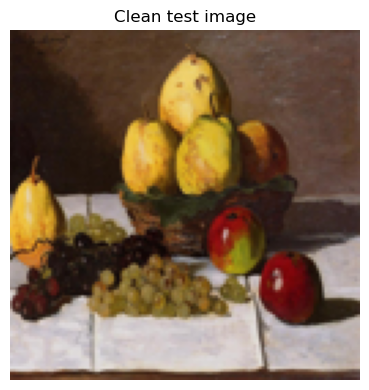

In [32]:
clean = load_image(TEST_PATH, IMAGE_SIZE)
H, W, C = clean.shape
print(f'Test image shape: {clean.shape}')

plt.figure(figsize=(4, 4))
plt.imshow(clean)
plt.title('Clean test image')
plt.axis('off')
plt.tight_layout()
plt.show()

## 8. Scenario A — Additive Gaussian Noise ($\sigma = 25$)

K-SVD was originally designed for Gaussian noise (l2 data fidelity).  
Here we expect both methods to perform similarly.

Noisy image   — PSNR: 22.46 dB   SSIM: 0.5141

Running K-SVD transform...
Transforming data with mean ...
Final error after transformation: 10.9707
Transforming data with mean ...


/var/folders/lp/166gmbq56sb3m0xjhm19215w0000gn/T/ipykernel_54778/228061670.py:55: RuntimeWarning: divide by zero encountered in matmul
  ksvd_patches[:, :, c] = (D_k @ X_k).T
/var/folders/lp/166gmbq56sb3m0xjhm19215w0000gn/T/ipykernel_54778/228061670.py:55: RuntimeWarning: overflow encountered in matmul
  ksvd_patches[:, :, c] = (D_k @ X_k).T
/var/folders/lp/166gmbq56sb3m0xjhm19215w0000gn/T/ipykernel_54778/228061670.py:55: RuntimeWarning: invalid value encountered in matmul
  ksvd_patches[:, :, c] = (D_k @ X_k).T


Error after transformation: 7.3905
Transforming data with mean ...
Final error after transformation: 10.6930
Transforming data with mean ...


/var/folders/lp/166gmbq56sb3m0xjhm19215w0000gn/T/ipykernel_54778/228061670.py:59: RuntimeWarning: divide by zero encountered in matmul
  l1ksvd_patches[:, :, c] = (D_l @ X_l).T
/var/folders/lp/166gmbq56sb3m0xjhm19215w0000gn/T/ipykernel_54778/228061670.py:59: RuntimeWarning: overflow encountered in matmul
  l1ksvd_patches[:, :, c] = (D_l @ X_l).T
/var/folders/lp/166gmbq56sb3m0xjhm19215w0000gn/T/ipykernel_54778/228061670.py:59: RuntimeWarning: invalid value encountered in matmul
  l1ksvd_patches[:, :, c] = (D_l @ X_l).T


Error after transformation: 7.2166
Transforming data with mean ...
Final error after transformation: 9.9507
Transforming data with mean ...
Error after transformation: 6.5317
Noisy image   — PSNR: 22.46 dB   SSIM: 0.5141
K-SVD         — PSNR: 24.45 dB   SSIM: 0.6482
l1-K-SVD      — PSNR: 25.97 dB   SSIM: 0.6586


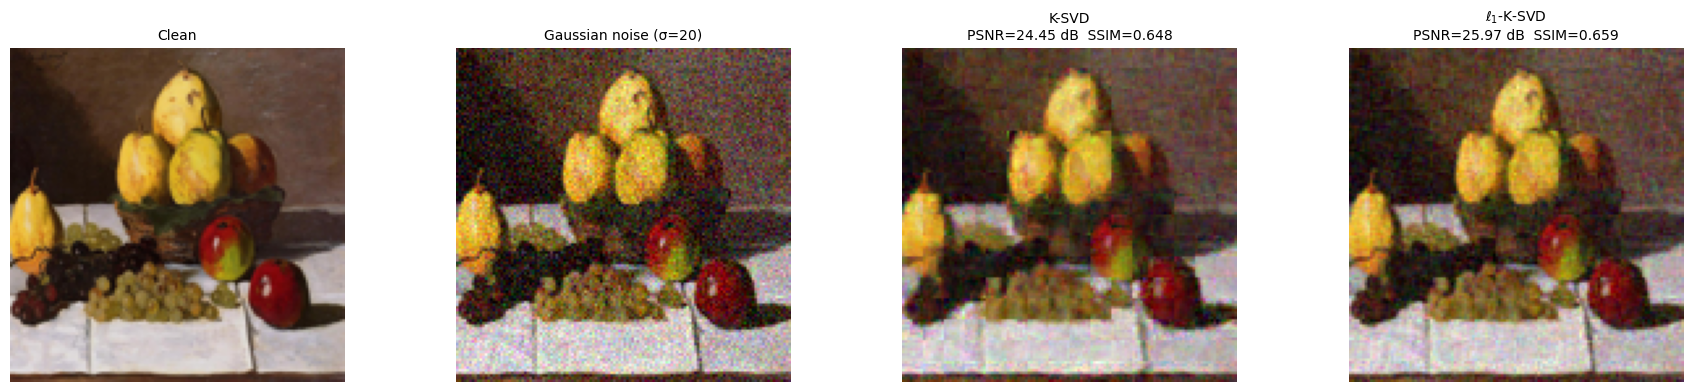

In [33]:
# Add Gaussian noise
gauss_noise  = np.random.normal(0, SIGMA_GAUSS, clean.shape).astype(np.float32)
noisy_gauss  = np.clip(clean + gauss_noise, 0, 1)

psnr_noisy_g  = psnr(clean, noisy_gauss, data_range=1.0)
ssim_noisy_g  = ssim(clean, noisy_gauss, data_range=1.0, channel_axis=2)
print(f'Noisy image   — PSNR: {psnr_noisy_g:.2f} dB   SSIM: {ssim_noisy_g:.4f}')

# Reconstruct with both models
print('\nRunning K-SVD transform...')
ksvd_rec_g, l1ksvd_rec_g = denoise_image(
    noisy_gauss, ksvd_models, l1ksvd_models, PATCH_SIZE
)

psnr_n, ssim_n = compute_metrics(clean, noisy_gauss)
psnr_k_g, ssim_k_g = compute_metrics(clean, ksvd_rec_g)
psnr_l_g, ssim_l_g = compute_metrics(clean, l1ksvd_rec_g)

print(f'Noisy image   — PSNR: {psnr_n:.2f} dB   SSIM: {ssim_n:.4f}')
print(f'K-SVD         — PSNR: {psnr_k_g:.2f} dB   SSIM: {ssim_k_g:.4f}')
print(f'l1-K-SVD      — PSNR: {psnr_l_g:.2f} dB   SSIM: {ssim_l_g:.4f}')

show_comparison(clean, noisy_gauss, ksvd_rec_g, l1ksvd_rec_g,
                f'Gaussian noise (σ={SIGMA_GAUSS*255:.0f})',
                psnr_k_g, ssim_k_g, psnr_l_g, ssim_l_g)

## 9. Scenario B — Additive Laplacian Noise (same power as Gaussian)

Laplacian noise has heavier tails than Gaussian.  
The $\ell_1$-K-SVD was specifically designed to be robust to this type of noise.

Noisy image   — PSNR: 22.60 dB   SSIM: 0.5252

Running reconstructions...
Transforming data with mean ...
Final error after transformation: 10.9742
Transforming data with mean ...


/var/folders/lp/166gmbq56sb3m0xjhm19215w0000gn/T/ipykernel_54778/228061670.py:55: RuntimeWarning: divide by zero encountered in matmul
  ksvd_patches[:, :, c] = (D_k @ X_k).T
/var/folders/lp/166gmbq56sb3m0xjhm19215w0000gn/T/ipykernel_54778/228061670.py:55: RuntimeWarning: overflow encountered in matmul
  ksvd_patches[:, :, c] = (D_k @ X_k).T
/var/folders/lp/166gmbq56sb3m0xjhm19215w0000gn/T/ipykernel_54778/228061670.py:55: RuntimeWarning: invalid value encountered in matmul
  ksvd_patches[:, :, c] = (D_k @ X_k).T


Error after transformation: 7.6060
Transforming data with mean ...
Final error after transformation: 10.5609
Transforming data with mean ...


/var/folders/lp/166gmbq56sb3m0xjhm19215w0000gn/T/ipykernel_54778/228061670.py:59: RuntimeWarning: divide by zero encountered in matmul
  l1ksvd_patches[:, :, c] = (D_l @ X_l).T
/var/folders/lp/166gmbq56sb3m0xjhm19215w0000gn/T/ipykernel_54778/228061670.py:59: RuntimeWarning: overflow encountered in matmul
  l1ksvd_patches[:, :, c] = (D_l @ X_l).T
/var/folders/lp/166gmbq56sb3m0xjhm19215w0000gn/T/ipykernel_54778/228061670.py:59: RuntimeWarning: invalid value encountered in matmul
  l1ksvd_patches[:, :, c] = (D_l @ X_l).T


Error after transformation: 7.4189
Transforming data with mean ...
Final error after transformation: 9.8601
Transforming data with mean ...
Error after transformation: 6.7908
K-SVD         — PSNR: 24.50 dB   SSIM: 0.6556
l1-K-SVD      — PSNR: 26.95 dB   SSIM: 0.7139


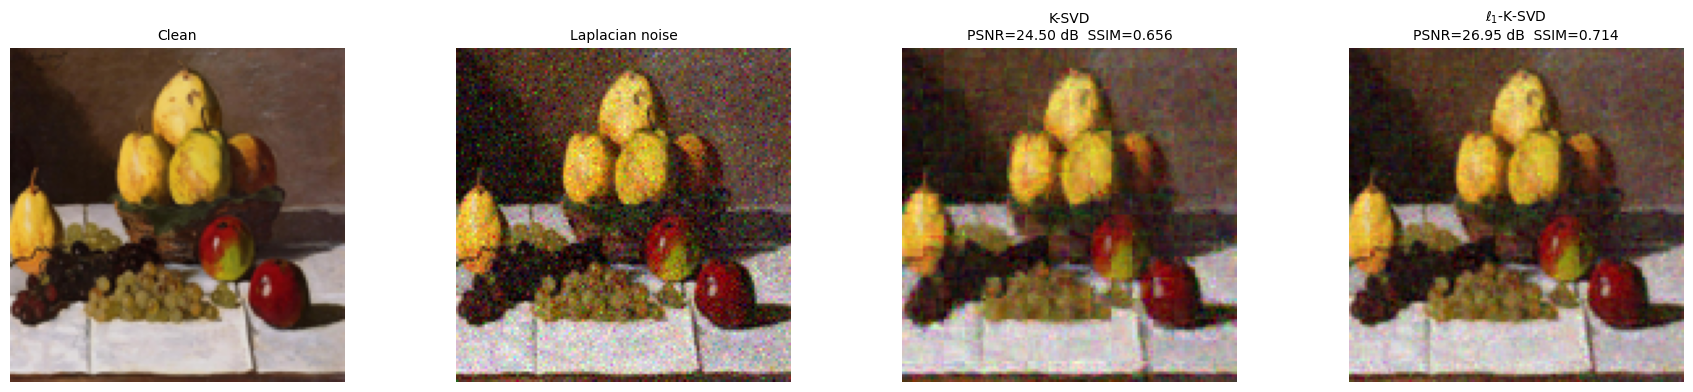

In [34]:
# Add Laplacian noise  (same RMS power as the Gaussian case)
lap_noise    = np.random.laplace(0, SCALE_LAP, clean.shape).astype(np.float32)
noisy_lap    = np.clip(clean + lap_noise, 0, 1)

psnr_noisy_l  = psnr(clean, noisy_lap, data_range=1.0)
ssim_noisy_l  = ssim(clean, noisy_lap, data_range=1.0, channel_axis=2)
print(f'Noisy image   — PSNR: {psnr_noisy_l:.2f} dB   SSIM: {ssim_noisy_l:.4f}')

print('\nRunning reconstructions...')
ksvd_rec_l, l1ksvd_rec_l = denoise_image(
    noisy_lap, ksvd_models, l1ksvd_models, PATCH_SIZE
)

psnr_k_l, ssim_k_l = compute_metrics(clean, ksvd_rec_l)
psnr_l_l, ssim_l_l = compute_metrics(clean, l1ksvd_rec_l)

print(f'K-SVD         — PSNR: {psnr_k_l:.2f} dB   SSIM: {ssim_k_l:.4f}')
print(f'l1-K-SVD      — PSNR: {psnr_l_l:.2f} dB   SSIM: {ssim_l_l:.4f}')

show_comparison(clean, noisy_lap, ksvd_rec_l, l1ksvd_rec_l,
                'Laplacian noise',
                psnr_k_l, ssim_k_l, psnr_l_l, ssim_l_l)

## 10. Scenario C — Random Pixel Removal / Inpainting (50% missing)

Sparse corruptions (impulsive noise, dead pixels) are modelled here as  
randomly zeroed pixels.  The $\ell_1$ objective is theoretically better  
suited to this regime.

Corrupted     — PSNR: 14.03 dB   SSIM: 0.3763

Running inpainting...
Error after transformation: 30.1016


/var/folders/lp/166gmbq56sb3m0xjhm19215w0000gn/T/ipykernel_54778/228061670.py:82: RuntimeWarning: divide by zero encountered in matmul
  ksvd_patches[:, :, c] = (D_k @ X_k).T
/var/folders/lp/166gmbq56sb3m0xjhm19215w0000gn/T/ipykernel_54778/228061670.py:82: RuntimeWarning: overflow encountered in matmul
  ksvd_patches[:, :, c] = (D_k @ X_k).T
/var/folders/lp/166gmbq56sb3m0xjhm19215w0000gn/T/ipykernel_54778/228061670.py:82: RuntimeWarning: invalid value encountered in matmul
  ksvd_patches[:, :, c] = (D_k @ X_k).T


Error after transformation: 29.5903
Error after transformation: 25.5192


/var/folders/lp/166gmbq56sb3m0xjhm19215w0000gn/T/ipykernel_54778/228061670.py:86: RuntimeWarning: divide by zero encountered in matmul
  l1ksvd_patches[:, :, c] = (D_l @ X_l).T
/var/folders/lp/166gmbq56sb3m0xjhm19215w0000gn/T/ipykernel_54778/228061670.py:86: RuntimeWarning: overflow encountered in matmul
  l1ksvd_patches[:, :, c] = (D_l @ X_l).T
/var/folders/lp/166gmbq56sb3m0xjhm19215w0000gn/T/ipykernel_54778/228061670.py:86: RuntimeWarning: invalid value encountered in matmul
  l1ksvd_patches[:, :, c] = (D_l @ X_l).T


Error after transformation: 24.9934
Error after transformation: 21.1970
Error after transformation: 20.6517
K-SVD         — PSNR: 25.69 dB   SSIM: 0.8171
l1-K-SVD      — PSNR: 31.00 dB   SSIM: 0.9356


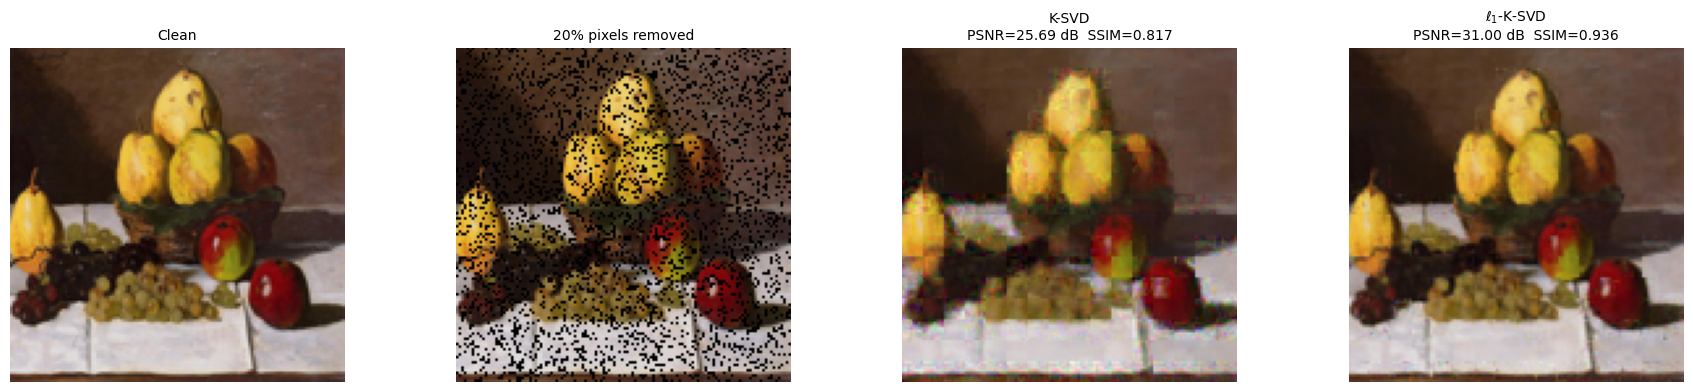

In [35]:
# Corrupt: zero out REMOVE_RATIO fraction of pixels
corrupted     = clean.copy()
mask          = np.random.random(clean.shape[:2]) < REMOVE_RATIO
corrupted[mask] = 0.0

psnr_noisy_c  = psnr(clean, corrupted, data_range=1.0)
ssim_noisy_c  = ssim(clean, corrupted, data_range=1.0, channel_axis=2)
print(f'Corrupted     — PSNR: {psnr_noisy_c:.2f} dB   SSIM: {ssim_noisy_c:.4f}')

print('\nRunning inpainting...')
ksvd_rec_c, l1ksvd_rec_c = inpaint_image(
    corrupted, ksvd_models, l1ksvd_models, PATCH_SIZE
)

psnr_k_c, ssim_k_c = compute_metrics(clean, ksvd_rec_c)
psnr_l_c, ssim_l_c = compute_metrics(clean, l1ksvd_rec_c)

print(f'K-SVD         — PSNR: {psnr_k_c:.2f} dB   SSIM: {ssim_k_c:.4f}')
print(f'l1-K-SVD      — PSNR: {psnr_l_c:.2f} dB   SSIM: {ssim_l_c:.4f}')

show_comparison(clean, corrupted, ksvd_rec_c, l1ksvd_rec_c,
                f'{int(REMOVE_RATIO*100)}% pixels removed',
                psnr_k_c, ssim_k_c, psnr_l_c, ssim_l_c)